<a href="https://colab.research.google.com/github/fboldt/aulasml/blob/master/aula12a_Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

In [ ]:
import pandas as pd

df = pd.read_csv('creditcard.csv')

print('Number of instances for each class:')
print(df['Class'].value_counts())

Number of instances for each class:
Class
0    284315
1       492
Name: count, dtype: int64


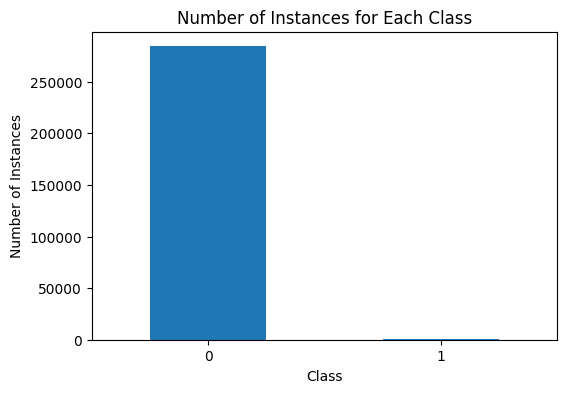

In [ ]:
import matplotlib.pyplot as plt

class_counts = df['Class'].value_counts()

plt.figure(figsize=(6, 4))
class_counts.plot(kind='bar')
plt.title('Number of Instances for Each Class')
plt.xlabel('Class')
plt.ylabel('Number of Instances')
plt.xticks(rotation=0)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

print('Number of instances in original dataset:')
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    stratify=y,
                                                    test_size=0.2,
                                                    random_state=42)
print('Number of instances in training set:')
print(y_train.value_counts())
print('Number of instances in test set:')
print(y_test.value_counts())

Number of instances in original dataset:
Class
0    284315
1       492
Name: count, dtype: int64
Number of instances in training set:
Class
0    227451
1       394
Name: count, dtype: int64
Number of instances in test set:
Class
0    56864
1       98
Name: count, dtype: int64


In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import confusion_matrix, accuracy_score

class ZeroR(BaseEstimator, TransformerMixin):
  def fit(self, X, y):
    self.most_frequent_class_ = y.value_counts().idxmax()
    return self

  def transform(self, X):
    y_pred = [self.most_frequent_class_] * len(X)
    return y_pred

model = ZeroR()
model.fit(X_train, y_train)
y_pred = model.transform(X_test)
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

[[56864     0]
 [   98     0]]
0.9982795547909132


In [ ]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression(tol=0.005)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[56832    32]
 [   26    72]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.69      0.73      0.71        98

    accuracy                           1.00     56962
   macro avg       0.85      0.87      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

y_pred_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred)
print('ROC AUC score:', roc_auc)


ROC AUC score: 0.8670655656747787


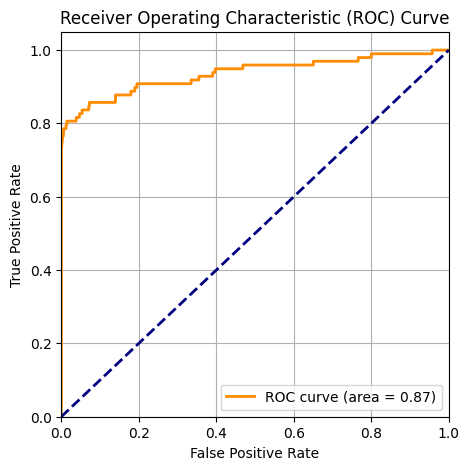

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

Precision-Recall AUC: 0.612508551101791


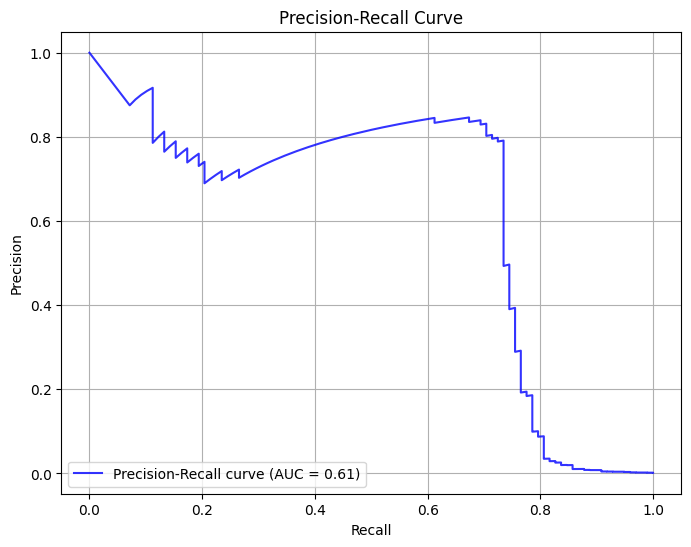

In [ ]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Calculate precision and recall
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)

# Calculate AUC
pr_auc = auc(recall, precision)

print('Precision-Recall AUC:', pr_auc)

# Plot the Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='b', alpha=0.8, label='Precision-Recall curve (AUC = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

In [ ]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)
print('Number of instances in resampled training set:')
print(y_train_resampled.value_counts())

model.fit(X_train_resampled, y_train_resampled)
y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Number of instances in resampled training set:
Class
0    227451
1    227451
Name: count, dtype: int64
[[54793  2071]
 [    8    90]]
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     56864
           1       0.04      0.92      0.08        98

    accuracy                           0.96     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.96      0.98     56962



In [ ]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)
print('Number of instances in resampled training set:')
print(y_train_resampled.value_counts())

model.fit(X_train_resampled, y_train_resampled)
y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Number of instances in resampled training set:
Class
0    394
1    394
Name: count, dtype: int64
[[54279  2585]
 [    8    90]]
              precision    recall  f1-score   support

           0       1.00      0.95      0.98     56864
           1       0.03      0.92      0.06        98

    accuracy                           0.95     56962
   macro avg       0.52      0.94      0.52     56962
weighted avg       1.00      0.95      0.98     56962



In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print('Number of instances in resampled training set:')
print(y_train_resampled.value_counts())

model.fit(X_train_resampled, y_train_resampled)
y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Number of instances in resampled training set:
Class
0    227451
1    227451
Name: count, dtype: int64
[[55592  1272]
 [    9    89]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.07      0.91      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.94      0.56     56962
weighted avg       1.00      0.98      0.99     56962



In [ ]:
from imblearn.under_sampling import NearMiss

nm = NearMiss(version=3)
X_train_resampled, y_train_resampled = nm.fit_resample(X_train, y_train)
print('Number of instances in resampled training set:')
print(y_train_resampled.value_counts())

model.fit(X_train_resampled, y_train_resampled)
y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Number of instances in resampled training set:
Class
0    394
1    394
Name: count, dtype: int64
[[53609  3255]
 [   10    88]]
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     56864
           1       0.03      0.90      0.05        98

    accuracy                           0.94     56962
   macro avg       0.51      0.92      0.51     56962
weighted avg       1.00      0.94      0.97     56962



# Abordagem ERRADA - Não fazer assim!

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

X_train_resampled, X_test_resampled, y_train_resampled, y_test_resampled = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)
model.fit(X_train_resampled, y_train_resampled)
y_pred = model.predict(X_test_resampled)
print(confusion_matrix(y_test_resampled, y_pred))
print(classification_report(y_test_resampled, y_pred))

[[55736  1014]
 [ 1954 55022]]
              precision    recall  f1-score   support

           0       0.97      0.98      0.97     56750
           1       0.98      0.97      0.97     56976

    accuracy                           0.97    113726
   macro avg       0.97      0.97      0.97    113726
weighted avg       0.97      0.97      0.97    113726



In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, StratifiedKFold

pipe = Pipeline([
    ('sampling', SMOTE(random_state=42)),
    ('model', LogisticRegression(tol=0.005))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_validate(pipe, X, y, cv=cv, scoring=['precision', 'recall', 'f1'])

print('Cross-validation scores:', scores)
print('Mean accuracy:', scores.mean())

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 654, in fit
    Xt = self._fit(X, y, routed_params, raw_params=params)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 562, in _fit
 

In [ ]:
from imblearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold

pipe = Pipeline([
    ('sampling', SMOTE(random_state=42)),
    ('model', LogisticRegression(tol=0.005))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_validate(pipe, X, y, cv=cv, scoring=['precision', 'recall', 'f1'])

print('Cross-validation scores:')
print(scores)


Cross-validation scores:
{'fit_time': array([17.72424173, 13.33802128, 14.84139776, 19.4215579 , 16.88993502]), 'score_time': array([0.04688716, 0.05073476, 0.09418082, 0.19579577, 0.04642153]), 'test_precision': array([0.07834101, 0.06980273, 0.07462687, 0.08302239, 0.06624606]), 'test_recall': array([0.85858586, 0.92929293, 0.91836735, 0.90816327, 0.85714286]), 'test_f1': array([0.14358108, 0.1298518 , 0.13803681, 0.15213675, 0.12298682])}


In [ ]:
from pprint import pprint
pprint(scores)

{'fit_time': array([17.72424173, 13.33802128, 14.84139776, 19.4215579 , 16.88993502]),
 'score_time': array([0.04688716, 0.05073476, 0.09418082, 0.19579577, 0.04642153]),
 'test_f1': array([0.14358108, 0.1298518 , 0.13803681, 0.15213675, 0.12298682]),
 'test_precision': array([0.07834101, 0.06980273, 0.07462687, 0.08302239, 0.06624606]),
 'test_recall': array([0.85858586, 0.92929293, 0.91836735, 0.90816327, 0.85714286])}


In [ ]:
from sklearn.preprocessing import StandardScaler

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('sampling', SMOTE(random_state=42)),
    ('model', LogisticRegression(tol=0.005))
])
scores = cross_validate(pipe, X, y, cv=cv, scoring=['precision', 'recall', 'f1'])
print('Cross-validation scores:')
pprint(scores)

Cross-validation scores:
{'fit_time': array([3.11523819, 2.31689954, 3.51116347, 2.40950632, 2.59695077]),
 'score_time': array([0.10583043, 0.11246085, 0.16516805, 0.11158609, 0.13857794]),
 'test_f1': array([0.12258953, 0.12223667, 0.1097561 , 0.11435832, 0.10691824]),
 'test_precision': array([0.06577975, 0.06532314, 0.05836576, 0.06097561, 0.05697051]),
 'test_recall': array([0.8989899 , 0.94949495, 0.91836735, 0.91836735, 0.86734694])}
